# 🤖 Notebook 04 — Model Training + WOA Optimization
### Quality-Aware FER | EfficientNet-B0 | CPU-Optimized

**Pipeline 3 Phase:**
1. **Baseline Training** — full training dengan augmentasi & Focal Loss
2. **WOA Optimization** — Whale Optimization Algorithm untuk hyperparameter search
3. **Retrain Optimal** — training ulang dengan hyperparameter terbaik dari WOA

**Dataset:** `dataset/train` dan `dataset/validation`
**Kelas:** 8 — angry, contempt, disgust, fear, happy, neutral, sad, suprise

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys, json, time, numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython import get_ipython
    if get_ipython() is not None:
        get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import seaborn as sns
import torch, torch.nn as nn
from pathlib import Path
from tqdm import tqdm

# Temukan ROOT project
current_path = Path(".").resolve()
if (current_path / "src").exists() and (current_path / "configs").exists():
    ROOT = current_path
elif (current_path.parent / "src").exists() and (current_path.parent / "configs").exists():
    ROOT = current_path.parent
else:
    ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
plt.style.use("dark_background")
SAVE_DIR = ROOT / "results" / "plots" / "training"; SAVE_DIR.mkdir(parents=True, exist_ok=True)
device   = "cpu"  # Full CPU mode

EMOTION_CLASSES = ["angry","contempt","disgust","fear","happy","neutral","sad","suprise"]
print(f"✅ Device: CPU | PyTorch: {torch.__version__}")
print(f"   EfficientNet-B0 — optimal untuk CPU")

✅ Device: CPU | PyTorch: 2.12.0+cpu
   EfficientNet-B0 — optimal untuk CPU


## 1. Load Config

In [2]:
from src.utils.config_loader import load_config
cfg = load_config(str(ROOT / "configs" / "default.yaml"))

# CPU-specific overrides
cfg["training"]["use_amp"]    = False   # tidak ada AMP di CPU
cfg["training"]["num_workers"] = 0      # Windows CPU: num_workers=0
cfg["dataset"]["image_size"]  = 224    # full resolution

print(f"\nConfig loaded (CPU-Optimized):")
print(f"  Backbone          : {cfg.model.backbone}")
print(f"  Num classes       : {cfg.model.num_classes}")
print(f"  Image size        : {cfg.dataset.image_size}x{cfg.dataset.image_size}")
print(f"  LR                : {cfg.training.lr}")
print(f"  Batch size        : {cfg.training.batch_size}")
print(f"  Epochs            : {cfg.training.epochs}")
print(f"  Focal Loss        : {cfg.training.use_focal_loss}")
print(f"  MixUp             : {cfg.training.use_mixup}")
print(f"  Freeze BB epochs  : {cfg.training.freeze_backbone_epochs}")
print(f"  Warmup epochs     : {cfg.training.warmup_epochs}")
print(f"  Early stop (F1)   : patience={cfg.training.early_stopping_patience}")


Config loaded (CPU-Optimized):
  Backbone          : efficientnet_b0
  Num classes       : 8
  Image size        : 224x224
  LR                : 0.001
  Batch size        : 32
  Epochs            : 50
  Focal Loss        : True
  MixUp             : True
  Freeze BB epochs  : 5
  Warmup epochs     : 5
  Early stop (F1)   : patience=12


## 2. Build Dataset & DataLoader

d:\BIG-Data\tuber\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Dataset loaded: Train=64,000 | Val=8,341

📊 Class weights (untuk Focal Loss):
   angry       : 1.0000
   contempt    : 1.0000
   disgust     : 1.0000
   fear        : 1.0000
   happy       : 1.0000
   neutral     : 1.0000
   sad         : 1.0000
   suprise     : 1.0000

Train batches: 2000 | Val batches: 131


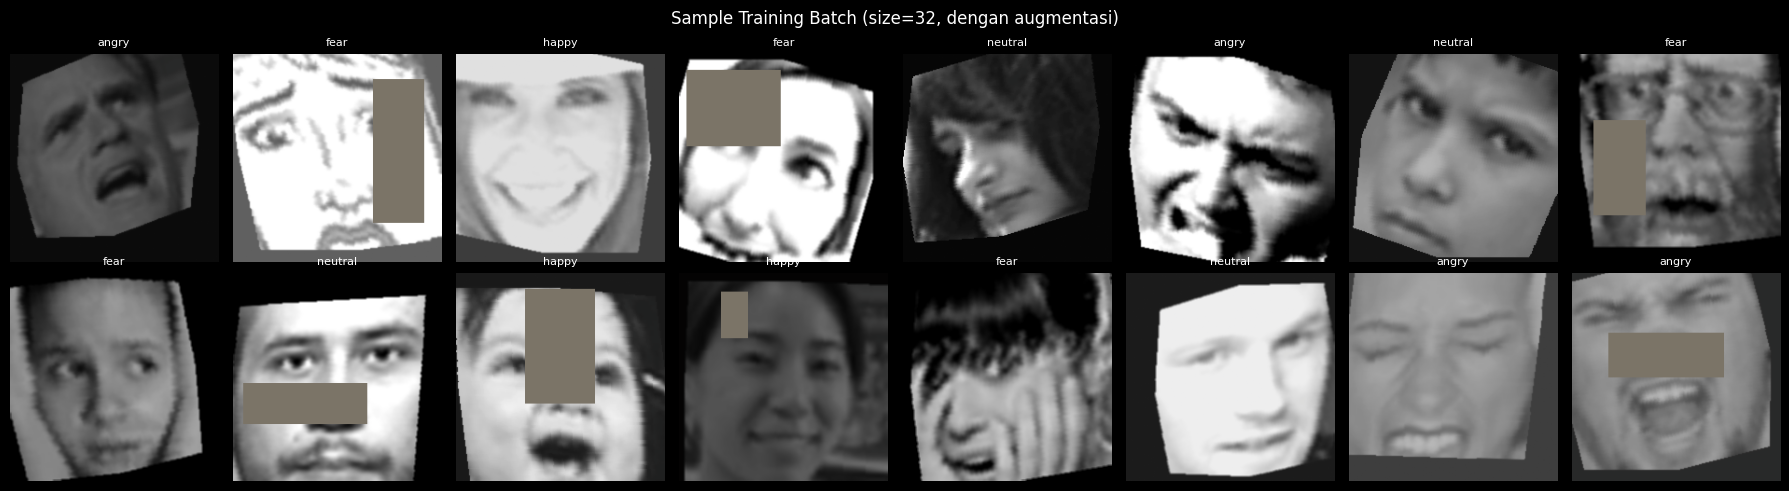

In [3]:
from src.fer.dataset    import FERDataset, get_dataloader
from src.fer.transforms import get_transforms
from src.fer.focal_loss import get_class_weights

data_root = str(ROOT / "dataset")

train_tf = get_transforms("train", image_size=cfg.dataset.image_size)
val_tf   = get_transforms("val",   image_size=cfg.dataset.image_size)

try:
    train_ds = FERDataset(root=data_root, split="train",      transform=train_tf)
    val_ds   = FERDataset(root=data_root, split="validation", transform=val_tf)
    print(f"✅ Dataset loaded: Train={len(train_ds):,} | Val={len(val_ds):,}")
except Exception as e:
    print(f"⚠️  Dataset error: {e}"); raise

# Hitung class weights untuk Focal Loss
class_weights = get_class_weights(train_ds, num_classes=cfg.model.num_classes)
print(f"\n📊 Class weights (untuk Focal Loss):")
for i, (emo, w) in enumerate(zip(EMOTION_CLASSES, class_weights)):
    print(f"   {emo:<12}: {w:.4f}")

train_loader = get_dataloader(train_ds, batch_size=cfg.training.batch_size,
                               shuffle=True, num_workers=0, use_weighted_sampler=True)
val_loader   = get_dataloader(val_ds,   batch_size=cfg.training.batch_size*2,
                               shuffle=False, num_workers=0)

print(f"\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# Visualisasi sample batch
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle(f"Sample Training Batch (size={cfg.training.batch_size}, dengan augmentasi)", color="white")
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
for i in range(min(16, len(images))):
    ax = axes[i//8][i%8]
    img = (images[i]*std+mean).permute(1,2,0).numpy().clip(0,1)
    ax.imshow(img); ax.set_title(EMOTION_CLASSES[labels[i].item()], color="white", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(SAVE_DIR/"01_sample_batch.png", dpi=120, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## 3. Model Architecture (EfficientNet-B0 + Head Baru)

In [4]:
from src.fer.model import FERModel

model = FERModel(
    num_classes=cfg.model.num_classes,
    dropout=cfg.model.dropout,
    pretrained=cfg.model.pretrained,
    backbone=cfg.model.backbone,
)

total_params = sum(p.numel() for p in model.parameters())
train_params = model.count_parameters()
print(f"✅ Model: {cfg.model.backbone}")
print(f"   Total params  : {total_params:,}")
print(f"   Trainable     : {train_params:,}")
print(f"   Classifier head: Linear(1280→512) + BN + GELU + Dropout + Linear(512→8)")

✅ Model: efficientnet_b0
   Total params  : 4,668,548
   Trainable     : 4,668,548
   Classifier head: Linear(1280→512) + BN + GELU + Dropout + Linear(512→8)


## ─────────────────────────────────────────────
## PHASE 1 — Baseline Training
## ─────────────────────────────────────────────

## 4. Baseline Training dengan Focal Loss + MixUp

In [ ]:
from src.fer.trainer import Trainer

# Reset model untuk baseline
model_baseline = FERModel(
    num_classes=cfg.model.num_classes,
    dropout=cfg.model.dropout,
    pretrained=cfg.model.pretrained,
    backbone=cfg.model.backbone,
)

trainer_baseline = Trainer(
    model=model_baseline,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.training.epochs,
    lr=cfg.training.lr,
    weight_decay=cfg.training.weight_decay,
    label_smoothing=cfg.training.label_smoothing,
    use_amp=False,   # CPU
    patience=cfg.training.early_stopping_patience,
    checkpoint_dir=str(ROOT / "checkpoints"),
    log_dir=str(ROOT / "checkpoints" / "logs"),
    device=device,
    warmup_epochs=cfg.training.get("warmup_epochs", 5),
    backbone_lr_factor=cfg.training.get("backbone_lr_factor", 0.02),
    freeze_backbone_epochs=cfg.training.get("freeze_backbone_epochs", 5),
    gradient_accumulation_steps=cfg.training.get("gradient_accumulation_steps", 2),
    use_tensorboard=False,
    min_lr=1e-6,
    monitor_metric="acc",
    # Focal Loss + MixUp
    use_focal_loss=cfg.training.get("use_focal_loss", True),
    focal_gamma=cfg.training.get("focal_gamma", 2.0),
    use_mixup=cfg.training.get("use_mixup", True),
    mixup_alpha=cfg.training.get("mixup_alpha", 0.2),
    class_weights=class_weights,
)

print("🚀 Memulai Baseline Training...")
print("   (ini akan memakan waktu — CPU bisa 10-30 menit tergantung dataset size)")
history_baseline = trainer_baseline.train()

[Trainer] Loss: FocalLoss(gamma=2.0, label_smoothing=0.1)
🚀 Memulai Baseline Training...
   (ini akan memakan waktu — CPU bisa 10-30 menit tergantung dataset size)
🚀 Training on CPU
[INFO] Backbone frozen. Only classifier will be trained.
   Trainable params : 661,000
   AMP              : False
   MixUp            : True (alpha=0.2)
   Monitor Metric   : acc



Epoch [  1/50] Train Loss: 1.4339 Acc: 0.2243 F1: 0.2240 | Val Loss: 1.1388 Acc: 0.4104 F1: 0.3938 | Time: 2054s
  ✅ Best model saved (epoch=1, val_acc=0.4104, val_f1=0.3938)


Epoch [  2/50] Train Loss: 1.2733 Acc: 0.2526 F1: 0.2516 | Val Loss: 1.1297 Acc: 0.4291 F1: 0.4154 | Time: 1794s
  ✅ Best model saved (epoch=2, val_acc=0.4291, val_f1=0.4154)


Train:  61%|██████████▎      | 1212/2000 [18:11<12:11,  1.08it/s, acc=0.2661, loss=0.7801]

## 5. Plot Training Curves — Baseline

In [ ]:
log_path = ROOT / "checkpoints" / "logs" / "training_log.csv"

if log_path.exists():
    log_df = pd.read_csv(log_path)
    run_starts = log_df[log_df["epoch"] == 1].index
    if len(run_starts) > 0:
        log_df = log_df.iloc[run_starts[-1]:].reset_index(drop=True)
else:
    log_df = pd.DataFrame({
        "epoch":      range(1, len(history_baseline["train_loss"])+1),
        "train_loss": history_baseline["train_loss"],
        "val_loss":   history_baseline["val_loss"],
        "train_acc":  history_baseline["train_acc"],
        "val_acc":    history_baseline["val_acc"],
        "val_f1":     history_baseline.get("val_f1", [0]*len(history_baseline["train_loss"])),
    })

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Baseline Training History", fontsize=14, color="white")

# Loss
ax = axes[0]
ax.plot(log_df["epoch"], log_df["train_loss"], color="#3b82f6", linewidth=2, label="Train Loss")
ax.plot(log_df["epoch"], log_df["val_loss"],   color="#f97316", linewidth=2, label="Val Loss", linestyle="--")
ax.set_title("Loss Curve", color="white"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(facecolor="#1e1e2e", labelcolor="white"); ax.set_facecolor("#1e1e2e"); ax.tick_params(colors="white")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Accuracy
ax2 = axes[1]
ax2.plot(log_df["epoch"], log_df["train_acc"]*100, color="#3b82f6", linewidth=2, label="Train Acc")
ax2.plot(log_df["epoch"], log_df["val_acc"]*100,   color="#f97316", linewidth=2, label="Val Acc", linestyle="--")
ax2.set_title("Accuracy Curve", color="white"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(facecolor="#1e1e2e", labelcolor="white"); ax2.set_facecolor("#1e1e2e"); ax2.tick_params(colors="white")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

# F1
ax3 = axes[2]
if "val_f1" in log_df.columns:
    ax3.plot(log_df["epoch"], log_df["val_f1"]*100, color="#22c55e", linewidth=2, label="Val Macro F1")
    ax3.set_title("Macro F1 Curve", color="white"); ax3.set_xlabel("Epoch"); ax3.set_ylabel("F1 (%)")
    ax3.legend(facecolor="#1e1e2e", labelcolor="white"); ax3.set_facecolor("#1e1e2e"); ax3.tick_params(colors="white")
    ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)
    best_f1 = log_df["val_f1"].max()
    ax3.axhline(best_f1*100, color="yellow", linestyle=":", linewidth=1.5, label=f"Best={best_f1*100:.1f}%")
    ax3.legend(facecolor="#1e1e2e", labelcolor="white")

plt.tight_layout()
plt.savefig(SAVE_DIR/"02_baseline_training_curves.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

best_val_acc = log_df["val_acc"].max()
best_val_f1  = log_df["val_f1"].max() if "val_f1" in log_df.columns else 0
print(f"🏆 Baseline — Best Val Acc: {best_val_acc*100:.2f}% | Best Val F1: {best_val_f1*100:.2f}%")

## 6. Evaluasi Baseline (Confusion Matrix)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

ckpt_path = ROOT / "checkpoints" / "best_model.pth"
eval_model = FERModel.load_from_checkpoint(str(ckpt_path), device=device)
eval_model.eval()

all_preds_b, all_labels_b = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating Baseline"):
        logits = eval_model(images)
        preds  = logits.argmax(dim=-1)
        all_preds_b.extend(preds.numpy()); all_labels_b.extend(labels.numpy())

all_preds_b  = np.array(all_preds_b)
all_labels_b = np.array(all_labels_b)

report_b = classification_report(
    all_labels_b, all_preds_b,
    labels=list(range(len(EMOTION_CLASSES))),
    target_names=EMOTION_CLASSES, zero_division=0
)
print("\nBaseline Classification Report:\n"); print(report_b)

# Confusion matrix
cm_b      = confusion_matrix(all_labels_b, all_preds_b, labels=list(range(len(EMOTION_CLASSES))))
cm_norm_b = cm_b.astype(float) / (cm_b.sum(axis=1, keepdims=True) + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix — Baseline (Validation Set)", fontsize=13, color="white")
for ax, data, fmt, title in [
    (axes[0], cm_b,      "d",    "Raw Counts"),
    (axes[1], cm_norm_b, ".2f",  "Normalized (Recall)"),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", ax=ax,
                xticklabels=EMOTION_CLASSES, yticklabels=EMOTION_CLASSES,
                linewidths=0.5, annot_kws={"size":8})
    ax.set_title(title, color="white"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(colors="white")
plt.tight_layout()
plt.savefig(SAVE_DIR/"03_baseline_confusion_matrix.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

# Backup checkpoint baseline
import shutil
baseline_ckpt = ROOT / "checkpoints" / "baseline_model.pth"
shutil.copy2(str(ckpt_path), str(baseline_ckpt))
print(f"\n💾 Baseline model disimpan: {baseline_ckpt}")

## ─────────────────────────────────────────────
## PHASE 2 — WOA Hyperparameter Optimization
## ─────────────────────────────────────────────

Whale Optimization Algorithm (WOA) mencari hyperparameter terbaik
dengan evaluasi cepat menggunakan:
- Image size: 112×112 (lebih cepat di CPU)
- Quick epochs: 3 epoch per candidate
- Max samples: 1000 per kelas (subset)

⚠️ Estimasi waktu: **60–120 menit** di CPU tergantung dataset size.
Hasil disimpan ke `checkpoints/woa_best_params.json`.

In [ ]:
from src.fer.woa_optimizer import WOAOptimizer

# WOA search space (bounds)
WOA_BOUNDS = {
    "lr":             (1e-4, 5e-3),
    "dropout":        (0.2,  0.5),
    "weight_decay":   (1e-5, 5e-2),
    "label_smoothing":(0.05, 0.20),
    "focal_gamma":    (1.0,  3.0),
}

# Quick eval config (CPU-friendly)
QUICK_IMG_SIZE   = 112
QUICK_EPOCHS     = 3
QUICK_MAX_SAMPLES = 1000

# Dataset untuk quick eval (resolusi kecil)
quick_train_tf = get_transforms("train", image_size=QUICK_IMG_SIZE)
quick_val_tf   = get_transforms("val",   image_size=QUICK_IMG_SIZE)
quick_train_ds = FERDataset(root=data_root, split="train",      transform=quick_train_tf)
quick_val_ds   = FERDataset(root=data_root, split="validation", transform=quick_val_tf)

# Batasi sampel untuk kecepatan WOA
def limit_samples(dataset, max_per_class=QUICK_MAX_SAMPLES, seed=42):
    """Batasi dataset ke max_per_class sampel per kelas."""
    rng = np.random.default_rng(seed)
    labels = np.array([s[1] for s in dataset.samples])
    keep   = []
    for cls in np.unique(labels):
        idx     = np.where(labels == cls)[0]
        take    = min(len(idx), max_per_class)
        chosen  = rng.choice(idx, size=take, replace=False)
        keep.extend(chosen.tolist())
    rng.shuffle(keep)
    dataset.samples = [dataset.samples[i] for i in keep]
    return dataset

quick_train_ds = limit_samples(quick_train_ds, QUICK_MAX_SAMPLES)
quick_val_ds   = limit_samples(quick_val_ds,   QUICK_MAX_SAMPLES)

print(f"✅ Quick eval dataset: Train={len(quick_train_ds):,} | Val={len(quick_val_ds):,}")
print(f"   Image size: {QUICK_IMG_SIZE}×{QUICK_IMG_SIZE} | Epochs per candidate: {QUICK_EPOCHS}")

In [ ]:
def woa_fitness(params: dict) -> float:
    """
    Evaluasi hyperparameter dengan quick-training.
    Returns validation accuracy pada validation set (lebih tinggi = lebih baik).
    """
    from src.fer.trainer import Trainer
    from src.fer.model   import FERModel

    lr             = float(params["lr"])
    dropout        = float(params["dropout"])
    weight_decay   = float(params["weight_decay"])
    label_smoothing = float(params["label_smoothing"])
    focal_gamma    = float(params["focal_gamma"])

    # Hitung class weights untuk dataset ini
    cw = get_class_weights(quick_train_ds, num_classes=cfg.model.num_classes)

    # Quick DataLoader
    qtrain_loader = get_dataloader(quick_train_ds, batch_size=32,
                                   shuffle=True, num_workers=0, use_weighted_sampler=True)
    qval_loader   = get_dataloader(quick_val_ds,   batch_size=64,
                                   shuffle=False, num_workers=0)

    # Fresh model
    qmodel = FERModel(
        num_classes=cfg.model.num_classes,
        dropout=dropout,
        pretrained=True,
        backbone=cfg.model.backbone,
    )

    # Quick trainer
    qtrainer = Trainer(
        model=qmodel,
        train_loader=qtrain_loader,
        val_loader=qval_loader,
        epochs=QUICK_EPOCHS,
        lr=lr,
        weight_decay=weight_decay,
        label_smoothing=label_smoothing,
        use_amp=False,
        patience=QUICK_EPOCHS + 1,  # no early stopping selama quick eval
        checkpoint_dir=str(ROOT / "checkpoints" / "woa_tmp"),
        log_dir=str(ROOT / "checkpoints" / "woa_tmp" / "logs"),
        device=device,
        warmup_epochs=1,
        freeze_backbone_epochs=1,
        backbone_lr_factor=0.02,
        gradient_accumulation_steps=2,
        use_tensorboard=False,
        min_lr=1e-7,
        monitor_metric="acc",
        use_focal_loss=True,
        focal_gamma=focal_gamma,
        use_mixup=True,
        mixup_alpha=0.2,
        class_weights=cw,
    )

    # Suppress output selama quick train
    import io, contextlib
    with contextlib.redirect_stdout(io.StringIO()):
        history = qtrainer.train()

    # Return best val Acc dari epoch terakhir
    final_acc = history["val_acc"][-1] if history["val_acc"] else 0.0
    return float(final_acc)

In [ ]:
# Jalankan WOA
woa = WOAOptimizer(
    bounds=WOA_BOUNDS,
    n_agents=cfg.woa.n_agents,    # 8
    max_iter=cfg.woa.max_iter,    # 12
    seed=42,
    minimize=False,   # maksimasi Accuracy
)

print("🐋 Memulai WOA Hyperparameter Search...")
print(f"   n_agents={cfg.woa.n_agents} | max_iter={cfg.woa.max_iter}")
print(f"   Estimasi waktu: {cfg.woa.n_agents * cfg.woa.max_iter * QUICK_EPOCHS * 0.5:.0f}–"
      f"{cfg.woa.n_agents * cfg.woa.max_iter * QUICK_EPOCHS * 2:.0f} menit")

best_woa_params = woa.optimize(woa_fitness, verbose=True)

# Simpan hasil WOA
woa_result_path = ROOT / "checkpoints" / "woa_best_params.json"
woa_result = {
    "best_params":   best_woa_params,
    "best_fitness":  woa.best_fitness,
    "history":       woa.history,
    "search_bounds": WOA_BOUNDS,
}
with open(woa_result_path, "w") as f:
    json.dump(woa_result, f, indent=2)

print(f"\n✅ WOA hasil disimpan: {woa_result_path}")
print(f"   Best Accuracy (quick eval): {woa.best_fitness:.4f}")
print(f"   Best params: {best_woa_params}")

## Plot WOA Convergence

In [ ]:
woa_iters  = [h["iter"] for h in woa.history]
woa_fitnesses = [h["best_fitness"] for h in woa.history]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(woa_iters, [f*100 for f in woa_fitnesses],
        color="#22c55e", linewidth=2.5, marker="o", markersize=5)
ax.fill_between(woa_iters, [f*100 for f in woa_fitnesses], alpha=0.15, color="#22c55e")
ax.set_title("WOA Convergence — Best Accuracy per Iterasi", color="white", fontsize=13)
ax.set_xlabel("Iterasi WOA", color="white"); ax.set_ylabel("Best Val Accuracy (%)", color="white")
ax.set_facecolor("#1e1e2e"); ax.tick_params(colors="white")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(SAVE_DIR/"04_woa_convergence.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## ─────────────────────────────────────────────
## PHASE 3 — Retrain dengan WOA Hyperparameter
## ─────────────────────────────────────────────

## 7. Load WOA Result & Retrain Full Model

In [ ]:
# Load WOA params (bisa dari file jika baru restart kernel)
woa_result_path = ROOT / "checkpoints" / "woa_best_params.json"
if woa_result_path.exists():
    with open(woa_result_path) as f:
        woa_result_loaded = json.load(f)
    best_woa_params = woa_result_loaded["best_params"]
    print(f"✅ WOA params loaded dari: {woa_result_path}")
    print(f"   Best params: {best_woa_params}")
else:
    print("⚠️  WOA result tidak ditemukan, gunakan config default")
    best_woa_params = {
        "lr": cfg.training.lr,
        "dropout": cfg.model.dropout,
        "weight_decay": cfg.training.weight_decay,
        "label_smoothing": cfg.training.label_smoothing,
        "focal_gamma": cfg.training.get("focal_gamma", 2.0),
    }

print(f"\n📋 Hyperparameter untuk Retrain:")
for k, v in best_woa_params.items():
    print(f"   {k:<20}: {v:.6f}")

In [ ]:
# Dataset full resolution untuk retrain
train_tf_full = get_transforms("train", image_size=224)
val_tf_full   = get_transforms("val",   image_size=224)
train_ds_full = FERDataset(root=data_root, split="train",      transform=train_tf_full)
val_ds_full   = FERDataset(root=data_root, split="validation", transform=val_tf_full)

cw_full       = get_class_weights(train_ds_full, num_classes=cfg.model.num_classes)

train_loader_full = get_dataloader(train_ds_full, batch_size=cfg.training.batch_size,
                                    shuffle=True, num_workers=0, use_weighted_sampler=True)
val_loader_full   = get_dataloader(val_ds_full,   batch_size=cfg.training.batch_size*2,
                                    shuffle=False, num_workers=0)

print(f"✅ Full dataset: Train={len(train_ds_full):,} | Val={len(val_ds_full):,}")

# Model baru
model_woa = FERModel(
    num_classes=cfg.model.num_classes,
    dropout=float(best_woa_params["dropout"]),
    pretrained=True,
    backbone=cfg.model.backbone,
)

# Trainer dengan WOA hyperparameter
trainer_woa = Trainer(
    model=model_woa,
    train_loader=train_loader_full,
    val_loader=val_loader_full,
    epochs=cfg.training.epochs,
    lr=float(best_woa_params["lr"]),
    weight_decay=float(best_woa_params["weight_decay"]),
    label_smoothing=float(best_woa_params["label_smoothing"]),
    use_amp=False,
    patience=cfg.training.early_stopping_patience,
    checkpoint_dir=str(ROOT / "checkpoints" / "woa_retrain"),
    log_dir=str(ROOT / "checkpoints" / "woa_retrain" / "logs"),
    device=device,
    warmup_epochs=cfg.training.get("warmup_epochs", 5),
    backbone_lr_factor=cfg.training.get("backbone_lr_factor", 0.02),
    freeze_backbone_epochs=cfg.training.get("freeze_backbone_epochs", 5),
    gradient_accumulation_steps=cfg.training.get("gradient_accumulation_steps", 2),
    use_tensorboard=False,
    min_lr=1e-6,
    monitor_metric="acc",
    use_focal_loss=True,
    focal_gamma=float(best_woa_params["focal_gamma"]),
    use_mixup=True,
    mixup_alpha=0.2,
    class_weights=cw_full,
)

print(f"\n🚀 Memulai Retrain dengan WOA Hyperparameter...")
history_woa = trainer_woa.train()

# Copy best model ke checkpoints root
import shutil
woa_ckpt = ROOT / "checkpoints" / "woa_retrain" / "best_model.pth"
final_ckpt = ROOT / "checkpoints" / "best_model.pth"
if woa_ckpt.exists():
    shutil.copy2(str(woa_ckpt), str(final_ckpt))
    print(f"\n💾 WOA best model disalin ke: {final_ckpt}")

## 8. Perbandingan: Baseline vs WOA-Optimized

In [ ]:
# Load log baseline
baseline_log_path = ROOT / "checkpoints" / "logs" / "training_log.csv"
woa_log_path      = ROOT / "checkpoints" / "woa_retrain" / "logs" / "training_log.csv"

baseline_log = pd.read_csv(baseline_log_path) if baseline_log_path.exists() else None
woa_log      = pd.read_csv(woa_log_path)      if woa_log_path.exists() else None

if baseline_log is not None and woa_log is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Baseline vs WOA-Optimized Training", fontsize=14, color="white")

    for ax, metric, ylabel in [
        (axes[0], "val_acc", "Validation Accuracy (%)"),
        (axes[1], "val_f1",  "Validation Macro F1 (%)"),
    ]:
        if metric in baseline_log.columns:
            ax.plot(baseline_log["epoch"], baseline_log[metric]*100,
                    color="#3b82f6", linewidth=2, label="Baseline", linestyle="--")
        if metric in woa_log.columns:
            ax.plot(woa_log["epoch"], woa_log[metric]*100,
                    color="#22c55e", linewidth=2.5, label="WOA-Optimized")
        ax.set_xlabel("Epoch", color="white"); ax.set_ylabel(ylabel, color="white")
        ax.set_title(ylabel, color="white"); ax.legend(facecolor="#1e1e2e", labelcolor="white")
        ax.set_facecolor("#1e1e2e"); ax.tick_params(colors="white")
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(SAVE_DIR/"05_baseline_vs_woa.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
    plt.show()

## 9. Per-Class Accuracy — WOA Model

In [ ]:
# Load WOA best model
final_ckpt = ROOT / "checkpoints" / "best_model.pth"
eval_model_woa = FERModel.load_from_checkpoint(str(final_ckpt), device=device)
eval_model_woa.eval()

all_preds_w, all_labels_w = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader_full, desc="Evaluating WOA Model"):
        logits = eval_model_woa(images)
        preds  = logits.argmax(dim=-1)
        all_preds_w.extend(preds.numpy()); all_labels_w.extend(labels.numpy())

all_preds_w  = np.array(all_preds_w)
all_labels_w = np.array(all_labels_w)

report_w = classification_report(
    all_labels_w, all_preds_w,
    labels=list(range(len(EMOTION_CLASSES))),
    target_names=EMOTION_CLASSES, zero_division=0
)
print("\nWOA-Optimized Classification Report:\n"); print(report_w)

# Per-class accuracy comparison
cm_w      = confusion_matrix(all_labels_w, all_preds_w, labels=list(range(len(EMOTION_CLASSES))))
cm_norm_w = cm_w.astype(float) / (cm_w.sum(axis=1, keepdims=True) + 1e-6)

per_class_acc_b = cm_norm_b.diagonal() if 'cm_norm_b' in dir() else np.zeros(len(EMOTION_CLASSES))
per_class_acc_w = cm_norm_w.diagonal()

COLORS_LIST = ["#ef4444","#a16207","#a855f7","#f97316","#22c55e","#94a3b8","#3b82f6","#eab308"]
fig, ax = plt.subplots(figsize=(12, 5))
x  = np.arange(len(EMOTION_CLASSES)); w = 0.35
ax.bar(x - w/2, per_class_acc_b*100, width=w, color=COLORS_LIST, alpha=0.5,
       edgecolor="white", linewidth=0.4, label="Baseline")
ax.bar(x + w/2, per_class_acc_w*100, width=w, color=COLORS_LIST, alpha=0.95,
       edgecolor="white", linewidth=0.4, label="WOA-Optimized")
for i, (b, w_acc) in enumerate(zip(per_class_acc_b, per_class_acc_w)):
    delta = (w_acc - b) * 100
    color = "#22c55e" if delta >= 0 else "#ef4444"
    ax.text(i+w/2, w_acc*100+1, f"{delta:+.1f}%", ha="center", va="bottom",
            color=color, fontsize=8, fontweight="bold")
ax.axhline(per_class_acc_w.mean()*100, color="yellow", linestyle="--", linewidth=2,
           label=f"WOA Mean UAR: {per_class_acc_w.mean()*100:.1f}%")
ax.set_xticks(x); ax.set_xticklabels(EMOTION_CLASSES, rotation=30, color="white")
ax.set_title("Per-Class Accuracy: Baseline vs WOA-Optimized", color="white", fontsize=13)
ax.set_ylabel("Accuracy (%)", color="white"); ax.tick_params(axis="y", colors="white")
ax.set_facecolor("#1e1e2e"); ax.set_ylim(0, 115)
ax.legend(facecolor="#1e1e2e", labelcolor="white")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_DIR/"06_per_class_comparison.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## 10. Ringkasan Akhir

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

baseline_acc = accuracy_score(all_labels_b, all_preds_b) if 'all_labels_b' in dir() else 0
baseline_f1  = f1_score(all_labels_b, all_preds_b, average="macro", zero_division=0) if 'all_labels_b' in dir() else 0
woa_acc      = accuracy_score(all_labels_w, all_preds_w)
woa_f1       = f1_score(all_labels_w, all_preds_w, average="macro", zero_division=0)

print("=" * 65)
print("📊 RINGKASAN HASIL TRAINING")
print("=" * 65)
print(f"\n{'Metrik':<22} {'Baseline':>12} {'WOA-Optimized':>14} {'Delta':>8}")
print("-" * 65)
print(f"{'Accuracy':<22} {baseline_acc*100:>11.2f}% {woa_acc*100:>13.2f}% "
      f"{(woa_acc-baseline_acc)*100:>+7.2f}%")
print(f"{'Macro F1':<22} {baseline_f1*100:>11.2f}% {woa_f1*100:>13.2f}% "
      f"{(woa_f1-baseline_f1)*100:>+7.2f}%")
print(f"{'UAR (per-class avg)':<22} {per_class_acc_b.mean()*100:>11.2f}% {per_class_acc_w.mean()*100:>13.2f}% "
      f"{(per_class_acc_w-per_class_acc_b).mean()*100:>+7.2f}%")
print("=" * 65)
print(f"\n💾 Model tersimpan:")
print(f"   Baseline  : checkpoints/baseline_model.pth")
print(f"   WOA Best  : checkpoints/best_model.pth")
print(f"   WOA Params: checkpoints/woa_best_params.json")
print("\n➡️  Next: Notebook 05 — Confidence Calibration")